Below, we give some intuition behind explainability in black-box models. We start from the simple case of Linear Regression, and then progress to more complex models.

In [75]:
import numpy as np
import pandas as pd
import sklearn
import shap
import matplotlib.pyplot as plt
import plotly.express as px
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

For this, we leverage the California Housing dataset as ground truth. Which takes the following variables associated with the price of the house:

- MedInc (float): Median income in block
- HouseAge (float): Median house age in block
- AveRooms (float): Average rooms in dwelling
- AveBedrms (float): Average bedrooms in dwelling
- Population (float): Block population
- AveOccup (float): Average house occupancy
- Latitude (float): House block latitude
- Longitude (float): House block longitude

In [76]:
X, y = shap.datasets.california(n_points=1000)

# Linear Regression

Linear regression is a simple yet powerful model that is particularly easy to interpret. This is because, after the model is fit, each variable is associated with a parameter (coefficient) that it is multiplied by, transforming its value into the units of the variable of interest. The sum of all these transformed variables, plus an offset (intercept), is what produces the final prediction.

For example, by analysing the parameters of an already fit house price prediction model, we can get an idea of how each variable influences the price of a house in our dataset:

HousePrice = MedInc * (0.4) + AveBedrms * (5000) + Latitude * (-0.5) + 50000

- The offset suggests that the baseline value of a house, when all variables are zero, is 50,000.
- Median income in the block (MedInc) increases the price of the house at a rate of 0.4 (each additional dollar in income adds 0.4 dollars to the predicted house price), and each additional bedroom adds 5,000 dollars.
- Latitude has a negative coefficient, suggesting that as we move north (latitude increases), house prices decrease. Since latitude increases northward, the negative coefficient implies a downward effect on price.

This initial interpretation is useful; however, there is an important limitation: the scale of the parameters can be misleading without context. If variables are not normalised, those with large numerical scales will tend to have smaller coefficients, and vice versa.

For example, if median house age ("HouseAge") were measured in seconds instead of years, its coefficient would be much smaller, simply because the input values are much larger. This could give the misleading impression that HouseAge is less important than other variables, when in reality the difference is only due to the units of measurement. In contrast, a variable like AveBedrms might have a larger coefficient simply because it operates on a smaller numerical scale.

Now to the actual model on our dataset:

In [77]:
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

print("Model coefficients:\n")
for i in range(X.shape[1]):
    print(X.columns[i], "=", model.coef_[i].round(5))
print("Intercept = ", model.intercept_.round(5))

Model coefficients:

MedInc = 0.42563
HouseAge = 0.01033
AveRooms = -0.1161
AveBedrms = 0.66385
Population = 3e-05
AveOccup = -0.26096
Latitude = -0.46734
Longitude = -0.46272
Intercept =  -37.92011


The analysis we did works well, but it provides a static, global understanding of how each variable affects the output across all samples. It fails to capture interactions between variables and is mainly limited to linear models. If we were using more complex models (e.g. neural networks or tree-based models), this type of interpretation would not be sufficient to understand the relationships being learned.

This is where SHAP comes in. SHAP (Shapley values) is a method based on game theory that allows us to understand the marginal contribution of each feature to a model’s prediction. We will omit the theory behind it, but intuitively, it tells us how much each feature contributes to the output, regardless of the model type.

Unlike linear regression coefficients, which provide a single global interpretation, SHAP allows us to compute per-sample explanations, showing how each feature contributes to an individual prediction, not just on average across the dataset.

Below, we take a subsample of the data to use as a reference dataset for comparisons (we could use the full dataset, but that would be computationally expensive). We then create an explainer object for the linear regression model we trained, compute the SHAP values (which represent the contribution of each feature to each prediction), and select a specific sample (sample #20) to analyse the relationships captured by the model.

In [78]:
X100 = shap.utils.sample(X, 100) # Subsample to use as background dataset
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)
sample_ind = 20

Having SHAP values computed allows us to draw different plots to better understand the reasons behind a model’s predictions.

## Dependence plot

A dependence plot helps us understand how the model output changes as a feature varies, as well as how frequently different values of that feature occur in the data.

More specifically, it shows how the model’s prediction evolves across the range of a feature, while also giving a sense of how common those values are. This helps us see not only the effect of a feature, but also how relevant that effect is in practice.

As a result, values that have a strong effect but occur rarely may end up being less important overall than values that have a weaker effect but occur frequently.

In the plot below, we show:

- The average value of the feature Latitude (grey vertical dashed line), at around 36
- The average model prediction (grey horizontal dashed line), at around 2
- The bold blue line represents the average model prediction as we vary Latitude across its range (this is the partial dependence, i.e. the global trend)
- The lighter blue lines represent the model predictions for individual samples as we vary Latitude (ICE curves). Each line corresponds to one sample, where we change only Latitude and keep the rest of the features fixed
- The red vertical segment marks the selected sample (sample_ind). It shows how that specific sample’s prediction shifts relative to the baseline (expected value), highlighting the contribution of Latitude for that instance

All the blue lines are linear because the underlying model is a linear regression. We can clearly see a negative relationship: as Latitude increases (moving north), the predicted house price decreases across all samples.


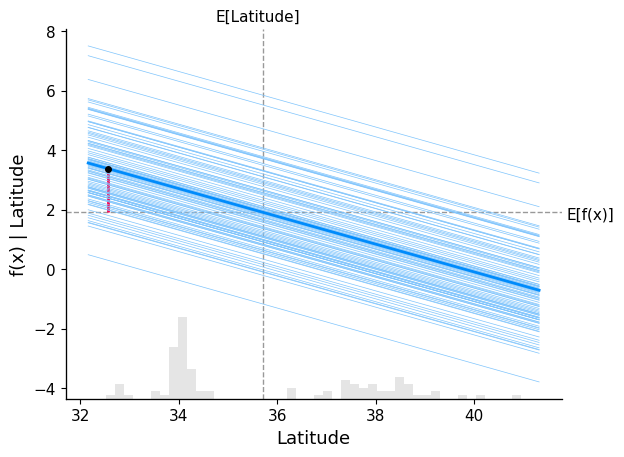

In [79]:

shap.partial_dependence_plot(
    "Latitude",
    model.predict,
    X100,
    ice=True, # Change to false to see only general trend
    model_expected_value=True,
    feature_expected_value=True,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

## Scatter Plot

Another way to visualise how a variable influences the model output is through a scatter plot. In this plot, we place the feature values on the x-axis and their corresponding SHAP values on the y-axis, showing how changes in the feature affect the prediction.

By passing shap_values to the color argument, SHAP automatically selects the feature that is most strongly correlated (or interacting) with the SHAP values of the selected feature, and uses it to colour the points.

In our example, we analyse Latitude, and SHAP identifies Longitude as the feature most related to it, which is then shown through the colour scale.

In this plot, we observe that:

- Points with lower latitude (further south) tend to have higher longitude values (red), meaning they are located more to the east
- Points with higher latitude (further north) tend to have lower longitude values (blue), meaning they are located more to the west

Note: if we look at the heatmap below, this pattern is consistent with the density of houses around the two main population centres in California: San Francisco (northwest) and Los Angeles (southeast).

The SHAP values follow a clear negative linear trend (as expected from a linear model), showing that as latitude increases, its contribution to the prediction decreases.

This implies that:

- Houses in the southeast (low latitude, high longitude) tend to have a positive contribution to the predicted price
- Houses in the northwest (high latitude, low longitude) tend to have a negative contribution

In other words, in this dataset, the model associates southeastern locations with higher predicted prices and northwestern locations with lower predicted prices. 

Note: It may be the case that houses in Los Angeles are more expensive than those in San Francisco, and that the geographic location of these cities is driving the pattern we observe. However, this analysis is purely observational, and we are not performing any hypothesis testing or causal inference here.

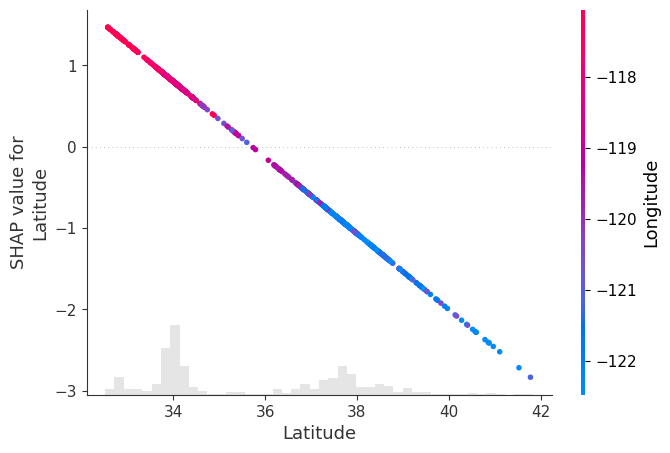

In [88]:
shap.plots.scatter(shap_values[:, "Latitude"], color=shap_values)

## Waterfall Plot

This plot gives us a per-sample explanation of the model’s prediction, showing how each variable contributed to the final output for a single observation, rather than how a variable behaves across the entire dataset.

In the plot below, we see how each feature contributes to moving the model’s expected value (the average prediction across all samples, E[f(X)]) to the final prediction for a specific sample (sample_ind).

Starting from an expected house price of E[f(X)]=1.904, each variable adds or subtracts from this baseline until we reach the final prediction for that sample, f(x)=1.681. We can verify this with:

In [80]:
model.predict(X.iloc[[sample_ind], :])

array([1.68076415])

From the plot, we observe that:

- Variables shown in blue contribute to pulling the prediction downwards
- Variables shown in red contribute to pushing the prediction upwards

The magnitude of each bar represents how much that feature contributes to the prediction for this specific sample.

These individual contributions are what we call SHAP values: they quantify how much each feature shifts the prediction away from the baseline E[f(X)] to reach the final output.

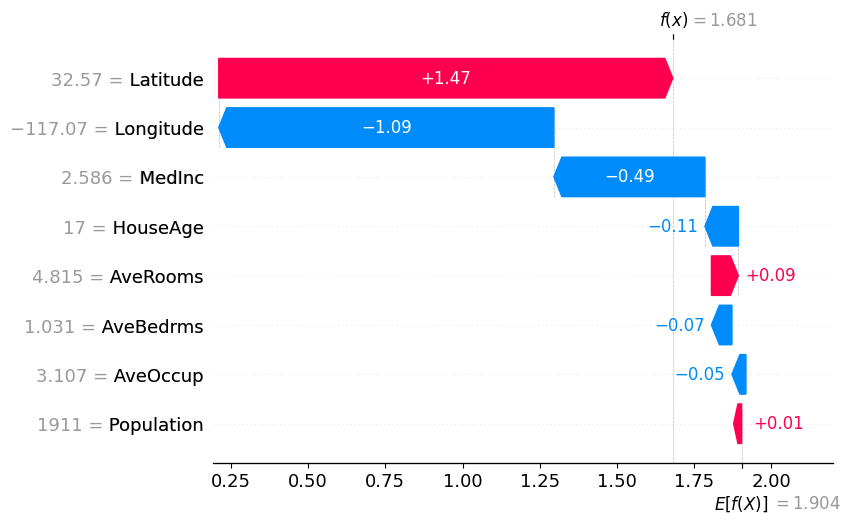

In [81]:
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

Note: Compare the waterfall plot and the dependence plot, and observe how the SHAP value for the Latitude variable is consistent across both.

## Beeswarm Plot

This plot shows the SHAP values of every variable across all samples. Each point represents a sample, positioned according to its SHAP value (impact on the model output), while the colour indicates the value of the feature (red = high value, blue = low value).

This allows us to understand both:

- how the value of a feature influences the prediction
- how common different effects are (denser regions indicate more samples with similar contributions)

Below is the beeswarm plot for our California housing dataset:

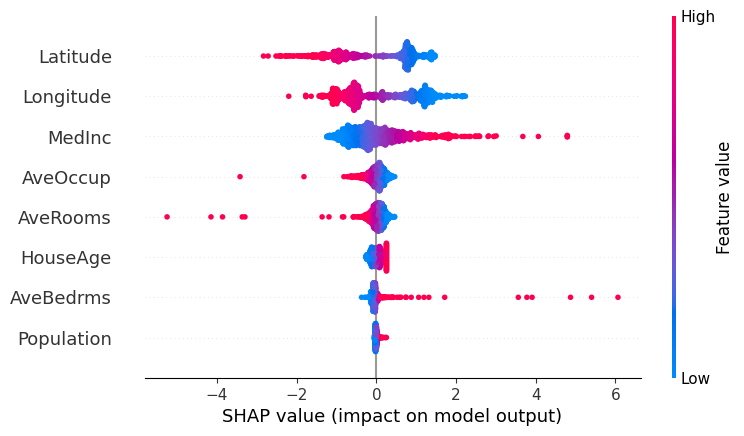

In [82]:
shap.plots.beeswarm(shap_values)

Analysing the plot, we can observe:

- MedInc and AveBedrms:
Both features show a right-skewed pattern in their SHAP values, with a few samples having very large positive contributions. In particular, higher values (red) are associated with strong positive SHAP values, meaning that higher income levels and a larger number of bedrooms tend to significantly increase the predicted house price.
These high-value observations are relatively rare but have a strong influence on the model’s predictions.

- AveOccup and AveRooms:
These features have SHAP values that are mostly concentrated around zero, indicating that for most samples they have a limited impact on the model’s prediction.
However, some high-value outliers (red points) show strong negative SHAP values, meaning that unusually high occupancy or number of rooms can significantly decrease the predicted house price.

- HouseAge and Population:
These features have SHAP values tightly clustered around zero, suggesting they have little to no impact on the model’s predictions overall.

- Latitude (North–South):
There is a clear pattern where higher latitude values (red, more northern locations) tend to have negative SHAP values, meaning they decrease the predicted house price.
Lower latitude values (blue, more southern locations) tend to have positive SHAP values, increasing the prediction.
This suggests that, in our dataset, houses further north tend to be cheaper, while those further south tend to be more expensive.

- Longitude (East–West):
We observe two main clusters of values. Lower longitude values (blue, more western locations) tend to have positive SHAP values, while higher longitude values (red, more eastern locations) tend to have negative SHAP values.

This Latitude-Longitude behaviour is consistent with the geographic distribution of the main population centres in California. If we plot the data on a map, we can clearly see two dense clusters: one in the northwest (San Francisco area) and one in the southeast (Los Angeles area).

Using a density map:

In [83]:
df = X.copy()
df["Price"] = y
meanlat = df.Latitude.mean()
meanlon = df.Longitude.mean()
fig = px.density_map(df, lat='Latitude', lon='Longitude', z="Price", radius=3,
                    center=dict(lat=meanlat, lon=meanlon), 
                    zoom=4.5,map_style="open-street-map")
fig.show()

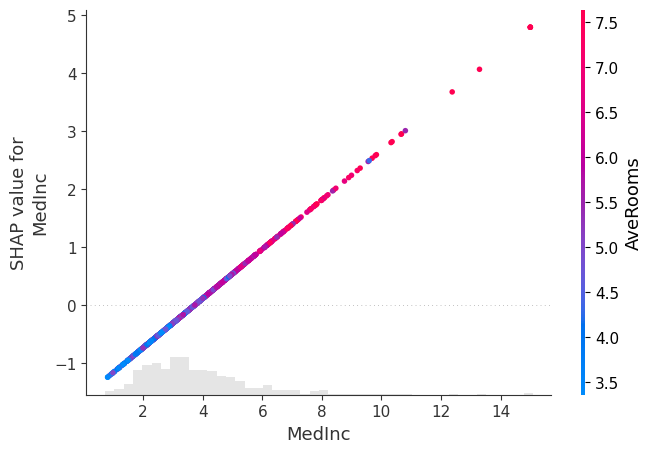

## Additive regression model

Content heavily inspired by the tutorials in: https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html